In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from traincae import DEFAULT_PARAMS, SlidingWindowDataset
from loadData import RawDataset, preprocess_hydraulic_data, preprocess_hydraulic_synthetic_dataset, obtain_ground_truth
from findAnomalies import load_model, reconstruct_signal_from_windows, keep_consecutive_true, compute_error, filter_faulty_df, get_faulty_signals, get_indexes_fault

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
unit = "VG5"
mode ="turbine"

training_df = pd.read_parquet(f'data/training_{unit}_{mode}.parquet')

# Create dataset for evaluation
train_dataset = SlidingWindowDataset(
    training_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)

scaler, threshold_df, model = load_model(unit = unit, mode = mode)

/home/matthieu/Documents/ML predictive maintenance/Project/MLPM/SERVERFILES_CAE/findAnomalies.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(mo

In [3]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '02',
    'anomaly_type': 'a',
    'set_type':'test_s02'
}

dataset_path = Path("../dataset")

rds_u5_buffer = RawDataset(dataset_path, "VG5", load_synthetic=False, load_training=False)

test_syn_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS["unit"],
                                                     number = SYNTHETIC_PARAMS["test_set"],
                                                     Type = SYNTHETIC_PARAMS["anomaly_type"],
                                                     scaler=scaler)


# Create dataset for evaluation
test_dataset = SlidingWindowDataset(
    test_syn_df,
    window=DEFAULT_PARAMS['window_size'],
    device=device
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=DEFAULT_PARAMS['batch_size'],
    shuffle=False  # Important: keep order for anomaly detection
)


In [4]:
reconstructed_test_df = reconstruct_signal_from_windows(test_loader, test_syn_df, model, device)

Reconstructing signals:   0%|          | 0/219 [00:00<?, ?it/s]

Reconstructing signals: 100%|██████████| 219/219 [00:10<00:00, 21.24it/s]


In [ ]:
error_test = compute_error(test_syn_df,reconstructed_test_df)

faulty_df = (error_test>threshold_df)
faulty_df = filter_faulty_df(faulty_df)

faulty_signals_df = get_faulty_signals(faulty_df)

ind_fault = get_indexes_fault(faulty_df, column="stat_coil_ph03_05_tmp")

Processing columns: 100%|██████████| 84/84 [00:19<00:00,  4.41it/s]


In [10]:
target_columns = faulty_signals_df.head(10).index

print(target_columns)

Index(['stat_coil_ph01_05_tmp', 'stat_coil_ph03_05_tmp', 'water_circ_hot_tmp',
       'air_circ_hot_02_tmp', 'stat_coil_ph02_05_tmp', 'air_circ_cold_04_tmp',
       'stat_magn_03_tmp', 'air_circ_cold_06_tmp', 'air_circ_cold_05_tmp',
       'air_circ_cold_02_tmp'],
      dtype='object')


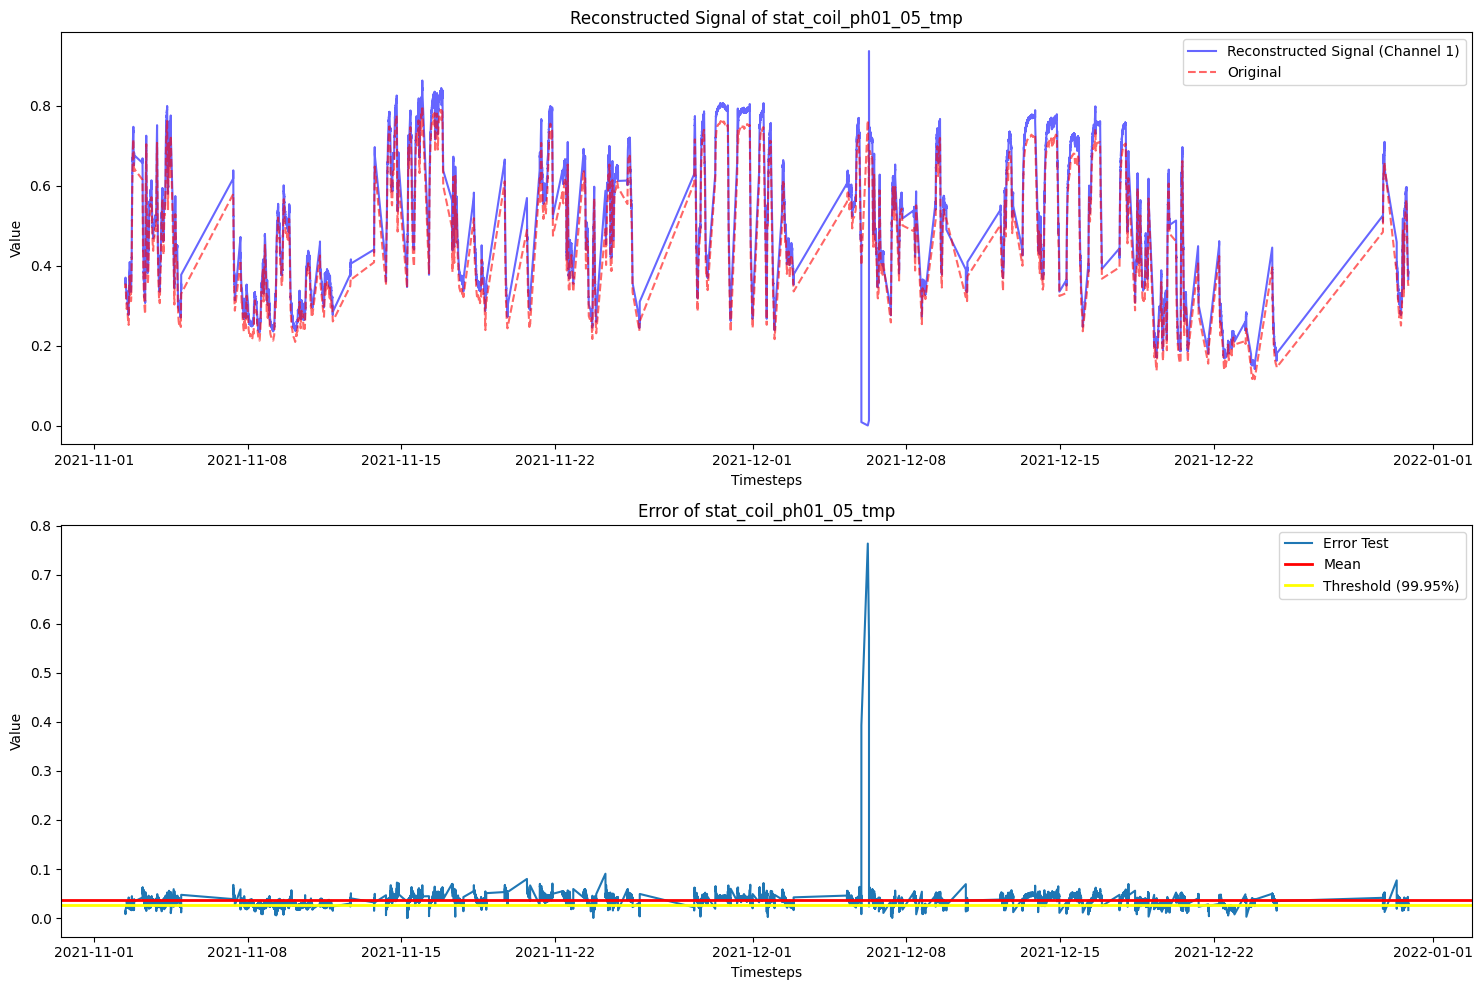

In [17]:
i=0 # Change the value to change the column

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# First subplot
ax1.plot(reconstructed_test_df[target_columns[i]], label='Reconstructed Signal (Channel 1)', color='b', alpha=0.6)
ax1.plot(test_syn_df[target_columns[i]], label="Original", color='r', linestyle='--', alpha=0.6)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Value')
ax1.set_title(f'Reconstructed Signal of {target_columns[i]}')
ax1.legend()

# Second subplot
ax2.plot(error_test[target_columns[i]], label="Error Test")
ax2.axhline(np.mean(error_test[target_columns[i]]), color='red', linewidth=2, label="Mean")
threshold = threshold_df[target_columns[i]]
ax2.axhline(threshold, color='yellow', linewidth=2, label="Threshold (99.95%)")
ax2.set_xlabel('Timesteps')
ax2.set_ylabel('Value')
ax2.set_title(f'Error of {target_columns[i]}')
ax2.legend()

plt.tight_layout()
plt.show()